# `AnalysisContainer` and `AnalysisContainerArray`: the central likelihood objects

This tutorial is a deep dive into `lisatools.analysiscontainer`. It goes one layer deeper than the general
[`lisatools_tutorial`](lisatools_tutorial.ipynb) notebook: rather than surveying every part of the package, we focus on how the
**container layer** combines data, noise information, and waveform generation into a single object that computes
inner products, signal-to-noise ratios, and likelihoods — in any analysis domain (frequency domain, wavelet/WDM domain, ...)
— and how many such containers are batched together for sampler-facing, per-walker computations.

Everything in this notebook is built synthetically in-process (a Galactic-binary injection generated with `gbgpu`);
no external data files are needed, and everything runs on the CPU.

**Outline**

1. Concepts: the three ingredients of an `AnalysisContainer`
2. A synthetic Galactic-binary dataset (frequency domain)
3. `AnalysisContainer` in the frequency domain: inner products, SNR, likelihoods, template comparisons
4. Registering a signal generator: `calculate_signal_*` and a 1-D likelihood scan
5. Residual workflows: subtracting templates from the data
6. Multi-model signal generators (how the global fit registers per-branch generators)
7. The WDM wavelet domain: same container API, different basis — with an FD ⟷ WDM comparison
8. `AnalysisContainerArray`: per-walker batching, vectorized likelihoods, and residual bookkeeping
9. Practical gotchas

## 1. Concepts

An `AnalysisContainer` combines three ingredients:

1. **Data / residual / template** — a `DomainBase` child from `lisatools.domains`: an array tagged with the settings of the
   basis it lives in. Concrete classes are `FDSignal` (frequency domain), `TDSignal` (time domain), `WDMSignal`
   (wavelet/WDM time–frequency domain), and `STFTSignal`. Each pairs an `(nchannels, *basis_shape)` array with a
   `*Settings` object (`FDSettings`, `TDSettings`, `WDMSettings`, `STFTSettings`) describing the grid.
   *(The older `DataResidualArray` wrapper is deprecated — pass a `DomainBase` child directly; it is transparently unwrapped
   if you still pass one.)*
2. **Sensitivity (noise) information** — a `SensitivityMatrixBase` subclass from `lisatools.sensitivity`, e.g.
   `XYZ2SensitivityMatrix` (the full 3×3 XYZ covariance for TDI-2, including XY/YZ/ZX cross terms) or
   `AET2SensitivityMatrix` (diagonal in the noise-orthogonal AET basis). The matrix is evaluated on the *same* domain
   settings as the data, and internally holds the inverse covariance `invC` and determinant `detC` used by likelihoods.
3. **(Optional) a signal generator** — a callable `fn(*params) -> DomainBase` (or a `{model_name: callable}` dict), so the
   container can build templates from source parameters on demand.

With those pieces, the container is the single object every analysis touches to evaluate

$$\log \mathcal{L}(\theta) = -\frac{1}{2}\left\langle d - h(\theta)\,|\,d - h(\theta)\right\rangle - \sum \log \det 2\pi \Sigma_n ,$$

where the noise-weighted inner product is

$$\langle a | b \rangle = 4\,\mathrm{Re} \sum_{ij} \sum_k \tilde a_i^*[k]\, \left[\Sigma_n^{-1}\right]_{ij}[k]\, \tilde b_j[k]\, \Delta ,$$

with $i, j$ running over TDI channels, $k$ over basis elements (frequency bins, wavelet pixels, ...), and $\Delta$ the domain's
differential element (`settings.differential_component`; `df` in FD, $1/4$ in WDM by convention). Because both the data and the
sensitivity carry their domain settings, the same container API works in every domain — we will exploit that in Section 7.

One sprint-wide convention worth knowing up front: **the compute backend (NumPy vs CuPy) is chosen at object construction**
via `force_backend=` on the settings objects (`"cpu"`, `"cuda12x"`, ...), never as a method keyword argument. Everything
derived from a settings object (arrays, sensitivity matrices, containers) inherits that backend, and array code follows the
`xp` pattern (`self.xp` is `numpy` or `cupy`). This notebook uses `force_backend="cpu"` throughout.

In [1]:
%matplotlib inline

import logging
import time
import warnings

import matplotlib.pyplot as plt
import numpy as np

logging.getLogger().setLevel(logging.WARNING)

# The stock LISA noise models evaluate 1/f terms at f = 0 when a full FFT grid
# (including DC) is used internally (e.g. while folding an FD PSD into the WDM
# basis). Those bins are masked downstream, so silence the numpy warnings here.
warnings.filterwarnings("ignore", category=RuntimeWarning)

import lisatools
from lisatools.analysiscontainer import AnalysisContainer, AnalysisContainerArray
from lisatools.detector import EqualArmlengthOrbits
from lisatools.domains import FDSettings, FDSignal, TDSettings, TDSignal, WDMSettings, WDMSignal
from lisatools.sensitivity import XYZ2SensitivityMatrix

print("lisatools:", lisatools.__file__)

lisatools: /Users/mkatz/Research/lisa_sprint_2026/LISAanalysistools/src/lisatools/__init__.py


## 2. A synthetic Galactic-binary dataset

We build a noiseless injection of a single Galactic binary (GB) directly in the frequency domain with
`gbgpu.gbgpu.GBGPU.generate_global_template` — the same recipe the stock global-fit synthetic data pipeline uses
(`lisatools.globalfit.stock.erebor.injections.SyntheticGBProcessingStep`). The generator fills a `(3, Nf)` complex buffer with
the TDI-2 X, Y, Z response to the binary on the natural rFFT grid of a time-domain observation with `N` samples of spacing `dt`.

Using noiseless data keeps every number in this tutorial exactly interpretable: the "data" *is* the signal, so a perfect
template gives $\langle d|h\rangle = \langle h|h\rangle = \langle d|d\rangle$, mismatch $= 0$, and residual log-likelihood
$= 0$ after subtraction. Adding a noise realization would only shift these quantities by their usual statistical
fluctuations.

We deliberately choose `N = Nf_wdm × Nt_wdm` with even wavelet-grid factors so the *same* time-domain grid can be poured
onto a WDM wavelet basis later (Section 7).

In [2]:
from gbgpu.gbgpu import GBGPU

dt = 10.0                    # time-domain sample spacing [s]
Nf_wdm, Nt_wdm = 256, 2048   # wavelet grid factors (Section 7); N = Nf * Nt
N = Nf_wdm * Nt_wdm          # number of TD samples
Tobs = N * dt                # observation time [s]
data_length = N // 2 + 1     # rFFT length
df = 1.0 / Tobs              # FD bin spacing [Hz]

print(f"Tobs = {Tobs:.4g} s = {Tobs / 86400:.1f} days | N = {N} | df = {df:.3e} Hz")

gb = GBGPU(force_backend="cpu", orbits=EqualArmlengthOrbits(force_backend="cpu"))
gb.gpus = None  # generate_global_template reads this attribute; None = CPU

# GB parameters: amplitude, frequency, frequency derivative, initial phase,
# inclination, polarization, ecliptic longitude, ecliptic latitude
amp, f0, fdot, phi0, iota, psi, lam, beta = (
    2e-22, 3.0e-3, 1.0e-17, 0.3, 0.7, 1.2, 2.0, 0.5,
)
truth = np.array([amp, f0, fdot, phi0, iota, psi, lam, beta])


def gb_fd_array(A, f0, fdot, phi0, iota, psi, lam, beta, oversample=4):
    "Generate one GB's TDI-2 XYZ response on the full rFFT grid -> (3, data_length) complex."
    params = np.atleast_2d(
        [A, f0, fdot, 0.0, phi0, iota, psi, lam, beta]  # fddot = 0.0
    ).astype(np.float64)
    buf = np.zeros(3 * data_length, dtype=np.complex128)
    gb.generate_global_template(
        params,
        np.zeros(params.shape[0], dtype=np.int32),  # group index (all -> buffer 0)
        buf,
        start_freq_ind=0,
        T=Tobs,
        dt=dt,
        tdi_channel_setup="XYZ",
        tdi2=True,
        oversample=oversample,
        data_length=data_length,
    )
    return buf.reshape(3, data_length)


injection_arr = gb_fd_array(*truth)
print("injection array:", injection_arr.shape, injection_arr.dtype)

Tobs = 5.243e+06 s = 60.7 days | N = 524288 | df = 1.907e-07 Hz


injection array: (3, 262145) complex128


### 2.1 Domain settings and band limiting

`FDSettings(N, df, min_freq=..., max_freq=...)` describes a uniform frequency grid `arange(N) * df`, optionally restricted to
an **active band**. Band limiting is central to how LISA analyses are organised (GB sources are analysed in narrow bands;
the global fit works band-by-band), so we set up three grids over the same underlying data:

- `fd_full` — the full rFFT grid (used *only* for domain transforms later; it includes $f=0$);
- `fd_wide` — a wide analysis band $[10^{-4}, 2.5\times 10^{-2}]$ Hz (the LISA bucket);
- `fd_band` — a narrow GB band $[2.5, 3.5]$ mHz around the injection.

Note how the band edges *snap to grid bins*: `min_freq` maps to `ind_min = ceil(min_freq / df)` and the active frequency
array `f_arr` starts there, not exactly at the requested value. `N_active` is the number of bins actually kept, and
`start_freq_ind` (on any FD `DomainBase`) reports the offset of the active band in the full grid.

In [3]:
fd_full = FDSettings(N=data_length, df=df, force_backend="cpu")
fd_wide = FDSettings(N=data_length, df=df, min_freq=1e-4, max_freq=2.5e-2, force_backend="cpu")
fd_band = FDSettings(N=data_length, df=df, min_freq=2.5e-3, max_freq=3.5e-3, force_backend="cpu")

for name, s in [("fd_full", fd_full), ("fd_wide", fd_wide), ("fd_band", fd_band)]:
    print(
        f"{name}: N={s.N} N_active={s.N_active} ind_min={s.ind_min} "
        f"f_arr[0]={float(s.f_arr[0]):.6e} f_arr[-1]={float(s.f_arr[-1]):.6e}"
    )

fd_full: N=262145 N_active=262145 ind_min=0 f_arr[0]=0.000000e+00 f_arr[-1]=5.000000e-02
fd_wide: N=262145 N_active=130548 ind_min=525 f_arr[0]=1.001358e-04 f_arr[-1]=2.500000e-02
fd_band: N=262145 N_active=5243 ind_min=13108 f_arr[0]=2.500153e-03 f_arr[-1]=3.499985e-03


### 2.2 The data as an `FDSignal`

An `FDSignal` pairs the array with its settings. A convenient behavior we rely on throughout: **if you construct an
`FDSignal` from a full-grid array (`shape[-1] == N`) with band-limited settings, it slices the array down to the active band
automatically.** So the same full-grid injection array can be dropped onto any of the three grids.

Below we plot the injected signal in characteristic-strain convention against the (square-root, characteristic-strain)
X-channel sensitivity, using the wide band. `DomainBase` provides `char_strain` ($\sqrt{f}\,|\tilde d(f)|$) and `loglog`
plotting helpers for FD signals; sensitivity matrices provide their own `loglog` (we use it in Section 3).

data_wide: FDSignal(N=262145, df=1.9073486328125e-07, min_freq=0.0001, max_freq=0.025, backend=cpu)
data_wide.shape: (3, 130548) | data_band.shape: (3, 5243)
data_band.start_freq_ind: 13108


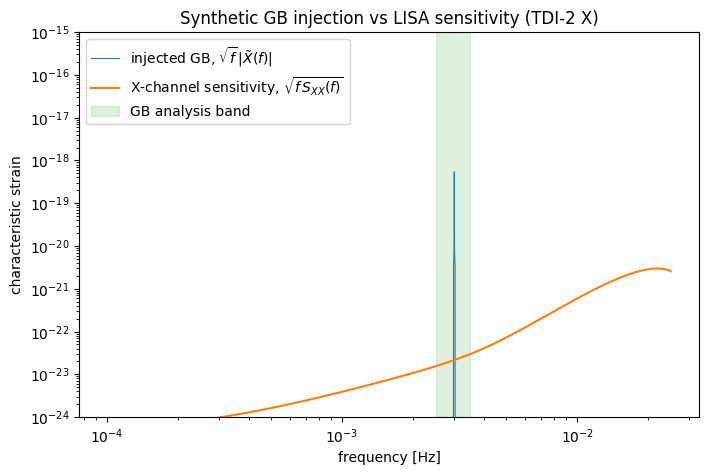

In [4]:
data_wide = FDSignal(injection_arr.copy(), fd_wide)   # auto-sliced to the wide band
data_band = FDSignal(injection_arr.copy(), fd_band)   # auto-sliced to the GB band

print("data_wide:", data_wide)
print("data_wide.shape:", data_wide.shape, "| data_band.shape:", data_band.shape)
print("data_band.start_freq_ind:", data_band.start_freq_ind)

# Build the sensitivity matrix on the wide band for plotting (Section 3 discusses it).
sens_wide = XYZ2SensitivityMatrix(fd_wide, model="sangria")

fig, ax = plt.subplots(figsize=(8, 5))
f_wide = np.asarray(fd_wide.f_arr)
ax.loglog(f_wide, np.asarray(data_wide.char_strain[0]), color="C0", lw=0.8,
          label=r"injected GB, $\sqrt{f}\,|\tilde{X}(f)|$")
ax.loglog(f_wide, np.sqrt(f_wide * np.asarray(sens_wide[(0, 0)])), color="C1",
          label=r"X-channel sensitivity, $\sqrt{f\,S_{XX}(f)}$")
ax.axvspan(float(fd_band.f_arr[0]), float(fd_band.f_arr[-1]), color="C2", alpha=0.15,
           label="GB analysis band")
ax.set_xlabel("frequency [Hz]")
ax.set_ylabel("characteristic strain")
ax.set_ylim(1e-24, 1e-15)
ax.legend(loc="upper left")
ax.set_title("Synthetic GB injection vs LISA sensitivity (TDI-2 X)")
plt.show()

## 3. `AnalysisContainer` in the frequency domain

Construct the container from the data and the sensitivity matrix. Two equivalent forms are supported:

- pass a `SensitivityMatrixBase` **instance** you built yourself, or
- pass the **class** plus `sens_mat_kwargs` — the container instantiates it on the fly as
  `sens_mat(data.settings, **sens_mat_kwargs)`, so you never repeat the settings extraction.

The `XYZ2SensitivityMatrix` used here is the full 3×3 Hermitian XYZ covariance for TDI-2 (the X, Y, Z channels share noise
sources, so the off-diagonal CSDs matter); `model="sangria"` picks the stock LDC Sangria instrument-noise levels. The matrix
exposes `invC` (the inverse covariance used inside every inner product) and `detC` (used by the noise term of the
likelihood); both are computed lazily on first access.

In [5]:
# Form 1: explicit instance
sens_band = XYZ2SensitivityMatrix(fd_band, model="sangria")
ac = AnalysisContainer(data_band, sens_band)

# Form 2: class + kwargs (instantiated internally on data_band.settings)
ac_alt = AnalysisContainer(
    FDSignal(injection_arr.copy(), fd_band),
    XYZ2SensitivityMatrix,
    sens_mat_kwargs=dict(model="sangria"),
)

print("sens_mat shape (channels x channels x N_active):", ac.sens_mat.shape)
print("invC shape:", ac.sens_mat.invC.shape, "| detC shape:", ac.sens_mat.detC.shape)
print("both forms agree:", np.isclose(ac.inner_product(), ac_alt.inner_product()))

sens_mat shape (channels x channels x N_active): (3, 3, 5243)
invC shape: (3, 3, 5243) | detC shape: (5243,)
both forms agree: True


The sensitivity matrix itself can be visualized. Each panel of the 3×3 grid below is one (cross-)spectral density
$|S_{ij}(f)|$ over the wide band: the diagonal panels are the X, Y, Z PSDs; the off-diagonal panels are the cross terms that
the full matrix treatment captures. Note we plot **magnitudes** — at these frequencies the XY/YZ/ZX cross-spectra are
*negative* (the built-in quick-look helper `sens_mat.loglog(char_strain=True)` takes a square root per panel, so it renders
only entries that are positive across the band — fine for diagonal matrices like `AET2SensitivityMatrix`, blank off-diagonal
panels for XYZ).

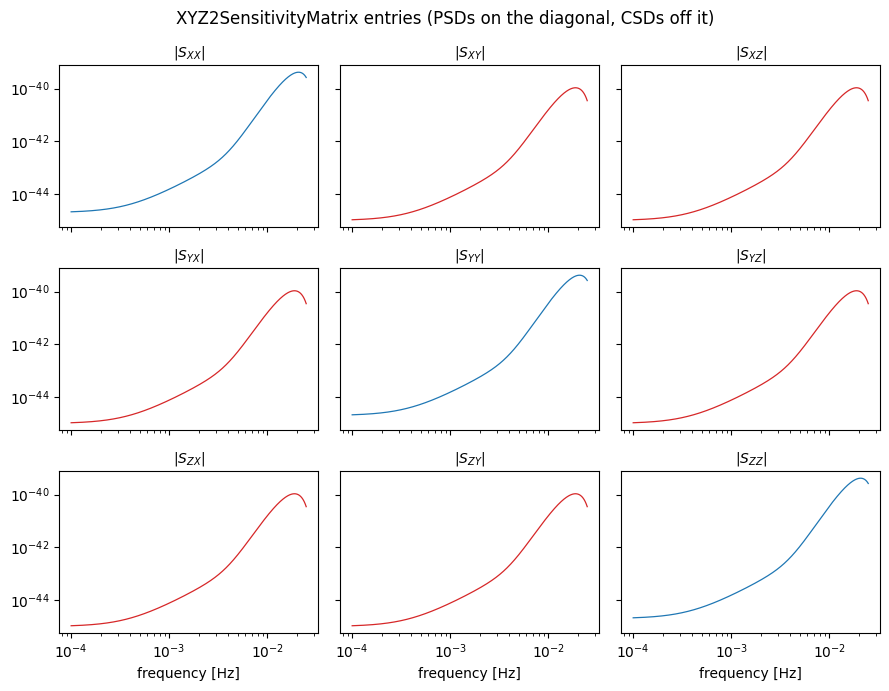

In [6]:
channels = "XYZ"
fig, axes = plt.subplots(3, 3, sharex=True, sharey=True, figsize=(9, 7))
for i in range(3):
    for j in range(3):
        axes[i, j].loglog(f_wide, np.abs(np.asarray(sens_wide.sens_mat[i, j])),
                          color="C0" if i == j else "C3", lw=0.9)
        axes[i, j].set_title(f"$|S_{{{channels[i]}{channels[j]}}}|$", fontsize=10)
for j in range(3):
    axes[-1, j].set_xlabel("frequency [Hz]")
fig.suptitle("XYZ2SensitivityMatrix entries (PSDs on the diagonal, CSDs off it)")
fig.tight_layout()
plt.show()

### 3.1 Data-level computations

With just data + sensitivity, the container evaluates quantities of the *stored array itself* (which, depending on your
workflow, is the raw data or a partially-subtracted residual):

- `ac.inner_product()` → $\langle d|d \rangle$,
- `ac.snr()` → $\sqrt{\langle d|d \rangle}$ (for noiseless signal-only data this is the injected **optimal SNR**),
- `ac.likelihood(source_only=True)` → $-\tfrac{1}{2}\langle d|d \rangle$ (the residual/source term),
- `ac.likelihood(noise_only=True)` → $-\sum_k \log \det \Sigma_n[k]$ (the PSD normalization term),
- `ac.likelihood()` → the sum of the two.

Because the GB carries essentially all of its power inside the narrow band, the band-limited container reproduces the
wide-band inner product to ~13 significant digits — at a fraction of the cost. This is precisely why the GB global fit
operates on narrow frequency bands.

In [7]:
ac_wide = AnalysisContainer(data_wide, sens_wide)

t0 = time.perf_counter()
d_d_wide = ac_wide.inner_product()
t_wide = time.perf_counter() - t0

t0 = time.perf_counter()
d_d_band = ac.inner_product()
t_band = time.perf_counter() - t0

print(f"<d|d> wide band  = {d_d_wide:.10f}   ({fd_wide.N_active} bins, {t_wide * 1e3:.1f} ms)")
print(f"<d|d> GB band    = {d_d_band:.10f}   ({fd_band.N_active} bins, {t_band * 1e3:.1f} ms)")
print(f"optimal SNR      = {ac.snr():.4f}")
print(f"log L source-only = {ac.likelihood(source_only=True):.4f}  (= -<d|d>/2)")
print(f"log L noise-only  = {ac.likelihood(noise_only=True):.4f}  (PSD normalization)")
print(f"log L full        = {ac.likelihood():.4f}")

<d|d> wide band  = 3472.5723333771   (130548 bins, 159.1 ms)
<d|d> GB band    = 3472.5723333771   (5243 bins, 0.7 ms)
optimal SNR      = 58.9285
log L source-only = -1736.2862  (= -<d|d>/2)
log L noise-only  = 1575853.4537  (PSD normalization)
log L full        = 1574117.1675


### 3.2 Comparing a template against the data

The `template_*` methods take a template (`DomainBase` on the *same settings* as the data) and evaluate:

- `template_inner_product(h)` → $\langle d|h\rangle$. With `normalize=True` it returns the **normalized overlap**
  $\mathcal{O} = \langle d|h\rangle / \sqrt{\langle d|d\rangle \langle h|h\rangle}$, and with `complex=True` the complex value
  (its phase is the overall phase offset between data and template). The **mismatch** is
  $\mathrm{mm} = 1 - |\mathcal{O}|$ — this `template_inner_product(..., normalize=True, complex=True)` pattern is the
  canonical mismatch computation used throughout the sprint's validation work.
- `template_snr(h)` → the tuple `(optimal, detected)`: $\sqrt{\langle h|h\rangle}$ and
  $\langle d|h\rangle / \sqrt{\langle h|h\rangle}$.
- `template_likelihood(h)` → $-\tfrac{1}{2}\left(\langle d|d\rangle + \langle h|h\rangle - 2\langle d|h\rangle\right)$
  (add `include_psd_info=True` for the noise term).

For our noiseless data, a perfect template gives mismatch at machine precision, detected = optimal SNR, and
$\log\mathcal{L} = 0$. A template offset in frequency by a few FD bins decorrelates dramatically over a 60-day observation.

In [8]:
h_true = FDSignal(gb_fd_array(*truth), fd_band)

overlap = ac.template_inner_product(h_true, normalize=True, complex=True)
print("perfect template:")
print(f"  <d|h>            = {ac.template_inner_product(h_true):.6f}")
print(f"  overlap          = {overlap:.16f}")
print(f"  mismatch         = {1 - abs(overlap):.3e}")
print(f"  (opt, det) SNR   = {ac.template_snr(h_true)}")
print(f"  log L            = {ac.template_likelihood(h_true):.6e}")

p_off = truth.copy()
p_off[1] += 3 * df  # shift f0 by 3 frequency bins
h_off = FDSignal(gb_fd_array(*p_off), fd_band)
overlap_off = ac.template_inner_product(h_off, normalize=True, complex=True)
print(f"\ntemplate offset by 3 bins in f0 (df = {df:.2e} Hz):")
print(f"  overlap          = {overlap_off:.6f}")
print(f"  mismatch         = {1 - abs(overlap_off):.6f}")
print(f"  (opt, det) SNR   = {ac.template_snr(h_off)}")
print(f"  log L            = {ac.template_likelihood(h_off):.4f}")

perfect template:
  <d|h>            = 3472.572333
  overlap          = 0.9999999999999917-0.0000000000000002j
  mismatch         = 8.327e-15
  (opt, det) SNR   = (np.float64(58.928535815656545), np.float64(58.928535815656055))
  log L            = -2.910383e-11

template offset by 3 bins in f0 (df = 1.91e-07 Hz):
  overlap          = 0.014564+0.061526j
  mismatch         = 0.936773
  (opt, det) SNR   = (np.float64(58.94561015799279), np.float64(0.8582484223365886))
  log L            = -3422.9887


### 3.3 Phase and amplitude maximization

`template_snr` and `template_likelihood` accept `phase_maximize=True` (replace $\langle d|h\rangle$ by
$|\langle d|h\rangle|$, i.e. analytically maximize over a rigid overall phase) and `template_likelihood` additionally accepts
`amp_maximize=True` (analytically maximize over an overall amplitude rescaling). A template that is wrong *only* by an
overall phase recovers the full detected SNR under phase maximization. The complex $\langle d|h\rangle$ used for the
maximization is stored on the container as `ac.non_marg_d_h` after the call.

In [9]:
p_phase = truth.copy()
p_phase[3] += 1.0  # phi0 off by 1 radian
h_phase = FDSignal(gb_fd_array(*p_phase), fd_band)

opt, det = ac.template_snr(h_phase)
opt_m, det_m = ac.template_snr(h_phase, phase_maximize=True)
print(f"detected SNR, phase off by 1 rad : {det:.4f}")
print(f"detected SNR, phase-maximized    : {det_m:.4f}  (optimal = {opt:.4f})")
print(f"stored complex <d|h> phase       : {np.angle(ac.non_marg_d_h):.4f} rad")
print(f"log L raw / phase-max / amp+phase-max: "
      f"{ac.template_likelihood(h_phase):.4f} / "
      f"{ac.template_likelihood(h_phase, phase_maximize=True):.4e} / "
      f"{ac.template_likelihood(h_phase, phase_maximize=True, amp_maximize=True):.4e}")

detected SNR, phase off by 1 rad : 31.8392
detected SNR, phase-maximized    : 58.9285  (optimal = 58.9285)
stored complex <d|h> phase       : 1.0000 rad
log L raw / phase-max / amp+phase-max: -1596.3335 / -9.2768e-11 / -9.2768e-11


## 4. Registering a signal generator

Passing `signal_gen=` at construction (or setting `ac.signal_gen = fn` later) attaches a parameter → template map to the
container. The `calculate_signal_likelihood / calculate_signal_inner_product / calculate_signal_snr` methods then accept raw
source parameters, generate the template internally, and run the corresponding `template_*` computation. Keyword arguments
for the generator go through `waveform_kwargs=`.

Two important conversion behaviors happen inside (`AnalysisContainer._to_data_domain`):

- The generator may return a `DomainBase` in a **different domain** than the data — it is transformed into the data's
  settings automatically (we use this FD → WDM in Section 7).
- A raw NumPy/CuPy array return value is trusted to already live on the data's grid.

Here the generator returns an `FDSignal` on the *exact band settings of the data*, which is the fastest path (no conversion
needed) and mirrors how the global-fit engine registers per-branch generators (`Settings.signal_gen` in
`lisatools.globalfit`): the engine wraps *transform + waveform + domain projection* into one callable
`fn(*sampling_params) -> DomainBase` per source class.

In [10]:
def gb_signal_gen(A, f0, fdot, phi0, iota, psi, lam, beta, oversample=4):
    "Parameters -> band-limited FDSignal template on the data's grid."
    return FDSignal(
        gb_fd_array(A, f0, fdot, phi0, iota, psi, lam, beta, oversample=oversample),
        fd_band,
    )


ac.signal_gen = gb_signal_gen

print("log L at truth        :", f"{ac.calculate_signal_likelihood(*truth, source_only=True):.6e}")
# waveform_kwargs reach the generator: the injection used oversample=4, so asking the
# generator for oversample=8 produces a *slightly different* template and log L dips
# below zero -- proof the kwarg actually flowed through.
print("log L, oversample=8   :",
      f"{ac.calculate_signal_likelihood(*truth, source_only=True, waveform_kwargs=dict(oversample=8)):.6e}")
print("(opt, det) SNR at truth:", ac.calculate_signal_snr(*truth))

log L at truth        : -2.910383e-11
log L, oversample=8   : -2.042991e+00
(opt, det) SNR at truth: (np.float64(58.928535815656545), np.float64(58.928535815656055))


### 4.1 A 1-D likelihood scan

With the generator registered, scanning the likelihood over a parameter is a loop of `calculate_signal_likelihood` calls.
We scan the GB frequency in units of the FD bin width and plot both the source-only log-likelihood and the mismatch. The
likelihood peaks at zero (noiseless data) at the injected frequency and falls off over a few bins — the classic single-source
frequency ridge.

41-point scan in 0.38 s


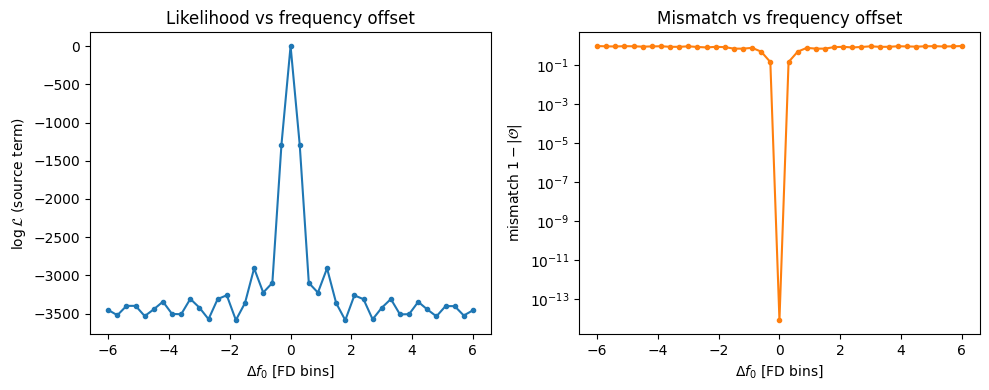

In [11]:
offsets_bins = np.linspace(-6.0, 6.0, 41)
scan_ll = np.empty_like(offsets_bins)
scan_mm = np.empty_like(offsets_bins)

t0 = time.perf_counter()
for i, ob in enumerate(offsets_bins):
    p = truth.copy()
    p[1] += ob * df
    h_i = gb_signal_gen(*p)
    scan_ll[i] = ac.template_likelihood(h_i)
    scan_mm[i] = 1.0 - abs(ac.template_inner_product(h_i, normalize=True, complex=True))
print(f"41-point scan in {time.perf_counter() - t0:.2f} s")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))
ax1.plot(offsets_bins, scan_ll, "o-", ms=3)
ax1.set_xlabel(r"$\Delta f_0$ [FD bins]")
ax1.set_ylabel(r"$\log\mathcal{L}$ (source term)")
ax1.set_title("Likelihood vs frequency offset")
ax2.semilogy(offsets_bins, np.clip(scan_mm, 1e-17, None), "o-", ms=3, color="C1")
ax2.set_xlabel(r"$\Delta f_0$ [FD bins]")
ax2.set_ylabel(r"mismatch $1 - |\mathcal{O}|$")
ax2.set_title("Mismatch vs frequency offset")
fig.tight_layout()
plt.show()

## 5. Residual workflows on a single container

The array held by the container is mutable in place, and in real analyses it usually stores a **residual** (data minus the
current best-fit templates). Two layers of API do this:

- `DomainBase.add_signal(template, sign=±1)` / `subtract_signal(template)` — the domain-aware, in-place add/subtract
  (handles partial band/time overlap between template and data in FD/TD/STFT);
- `AnalysisContainer.add_signal_to_data(template_or_params, sign=±1)` / `subtract_signal_from_data(...)` — the container-level
  wrappers, which also accept raw parameters (a template is generated via `signal_gen`).

After subtracting the exact injection, the residual is numerically zero and the source-only log-likelihood collapses to zero.

source-only log L before subtraction: -1736.2862
source-only log L after  subtraction: -0.0000e+00
source-only log L after re-adding   : -1736.2862


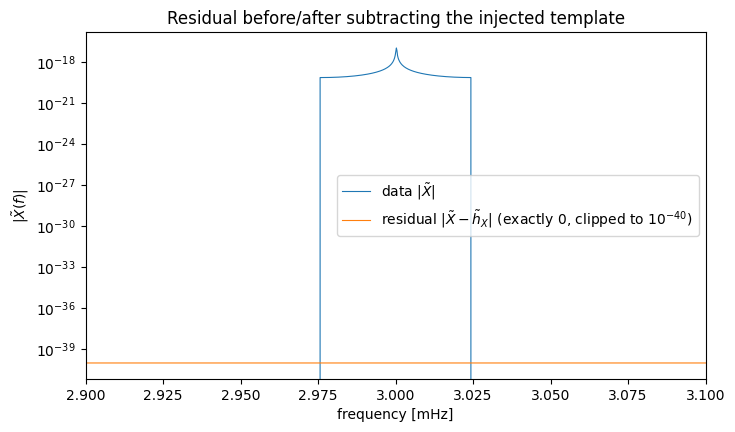

In [12]:
res_ll_before = ac.likelihood(source_only=True)

ac.subtract_signal_from_data(truth)   # generates the template from params via signal_gen
res_ll_after = ac.likelihood(source_only=True)

print(f"source-only log L before subtraction: {res_ll_before:.4f}")
print(f"source-only log L after  subtraction: {res_ll_after:.4e}")

residual_abs = np.abs(np.asarray(ac.data.arr[0]))  # keep for the plot below

ac.add_signal_to_data(truth)          # put the signal back for the next sections
print(f"source-only log L after re-adding   : {ac.likelihood(source_only=True):.4f}")

fig, ax = plt.subplots(figsize=(8, 4.5))
f_band = np.asarray(fd_band.f_arr)
ax.semilogy(f_band * 1e3, np.abs(np.asarray(ac.data.arr[0])), lw=0.8, label=r"data $|\tilde{X}|$")
ax.semilogy(f_band * 1e3, np.clip(residual_abs, 1e-40, None), lw=0.8,
            label=r"residual $|\tilde{X} - \tilde{h}_X|$ (exactly 0, clipped to $10^{-40}$)")
ax.set_xlabel("frequency [mHz]")
ax.set_ylabel(r"$|\tilde{X}(f)|$")
ax.set_xlim(2.9, 3.1)
ax.legend()
ax.set_title("Residual before/after subtracting the injected template")
plt.show()

## 6. Multi-model signal generators

`signal_gen` can be a **dict** `{model_name: callable}` — this is how the global-fit engine registers one generator per
source branch (GBs, MBHBs, EMRIs, ...) on each walker's container. In multi-model mode, the parameter argument to
`calculate_signal_*` is a dict `{model_name: params}` where each entry is a 1-D parameter set (single source) or a 2-D batch
`(n_sources, n_params)`; batched sources are **summed within each model** and then **across models** to form the combined
template that is compared to the data.

Passing `per_model_per_signal=True` skips the summation and instead returns the per-source values — handy for inspecting
individual contributions (e.g. per-source detected SNRs against the current residual).

In [13]:
ac.signal_gen = {"gb": gb_signal_gen}
print("is_multi_model:", ac.is_multi_model, "| model_names:", ac.model_names)

# a batch of two GBs: the injection plus a second, weaker source 20 bins away
second = truth.copy()
second[0] *= 0.5
second[1] += 20 * df
two_sources = np.vstack([truth, second])

ll_combined = ac.calculate_signal_likelihood({"gb": two_sources}, source_only=True)
print(f"combined 2-source template log L: {ll_combined:.4f}"
      "  (< 0: the second source is not in the data)")

per_source = ac.calculate_signal_snr({"gb": two_sources}, per_model_per_signal=True)
for i, (opt_i, det_i) in enumerate(per_source["gb"]):
    print(f"  source {i}: optimal SNR = {opt_i:.2f}, detected SNR vs data = {det_i:.2f}")

ac.signal_gen = gb_signal_gen  # back to single-model for the rest of the notebook

is_multi_model: True | model_names: ['gb']
combined 2-source template log L: -435.7496  (< 0: the second source is not in the data)
  source 0: optimal SNR = 58.93, detected SNR vs data = 58.93
  source 1: optimal SNR = 29.52, detected SNR vs data = 0.15


## 7. The WDM wavelet domain: same API, different basis

Everything above was frequency-domain, but nothing in the container API was FD-specific. We now pour the *same* data onto a
WDM wavelet (time–frequency) grid and rebuild the container there.

`WDMSettings(Nf, Nt, dt, min_freq=..., max_freq=...)` describes a wavelet grid with `Nf` frequency layers of width
`layer_df = 1 / (2 Nf dt)` and `Nt` time pixels of duration `layer_dt = Nf dt` (so `Nf * Nt` equals the number of TD samples —
which is why we chose `N = 256 × 2048` in Section 2). Like `FDSettings`, it supports band limiting: `min_freq` / `max_freq`
snap to whole *layers* (`ind_min_f = ceil(min_freq / layer_df)`), and the signal array carries only the active
`(Nf_active, Nt_active)` block. Note that WDM coefficients are **real-valued** (dtype `float`), unlike complex FD bins.

Domain conversion is a single `transform` call on any `DomainBase`: here FD → WDM from the **full-grid** FD signal.
(Always transform from the full grid — see the gotchas in Section 9.)

layer_df = 1.9531e-04 Hz | layer_dt = 2560 s
active layers: ind_min_f=13 .. ind_max_f=17 -> Nf_active=5, Nt_active=2048
data_wdm: (3, 5, 2048) float64


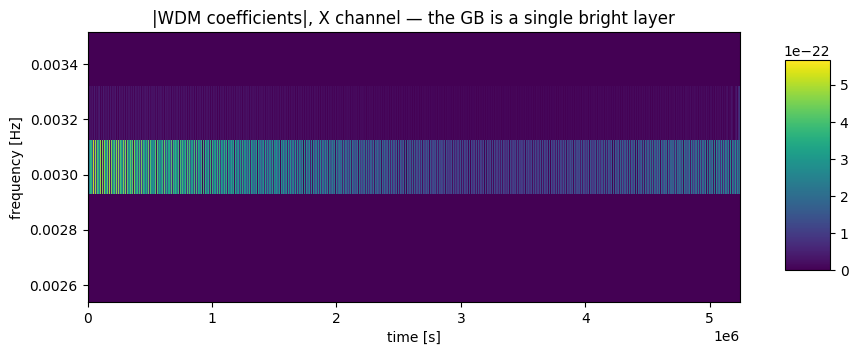

In [14]:
wdm_band = WDMSettings(Nf_wdm, Nt_wdm, dt, min_freq=2.5e-3, max_freq=3.5e-3, force_backend="cpu")
print(f"layer_df = {wdm_band.layer_df:.4e} Hz | layer_dt = {wdm_band.layer_dt:.0f} s")
print(f"active layers: ind_min_f={wdm_band.ind_min_f} .. ind_max_f={wdm_band.ind_max_f} "
      f"-> Nf_active={wdm_band.Nf_active}, Nt_active={wdm_band.Nt_active}")

data_wdm = FDSignal(injection_arr.copy(), fd_full).transform(wdm_band)
print("data_wdm:", data_wdm.shape, data_wdm.arr.dtype)

fig, ax = plt.subplots(figsize=(9, 3.5))
fig, ax = data_wdm.heatmap(index=0, mag=True, fig=fig, ax=ax, cax=None, add_cax=True,
                           cmap="viridis")
ax.set_xlabel("time [s]")
ax.set_ylabel("frequency [Hz]")
ax.set_title("|WDM coefficients|, X channel — the GB is a single bright layer")
plt.show()

### 7.1 A WDM sensitivity matrix and container

`XYZ2SensitivityMatrix` accepts the WDM settings directly: internally, `get_sensitivity` **folds** the full-resolution FD
(cross-)PSDs into the wavelet basis (`wdm_psd_method="fold"`, the default, calibrated so that a stationary noise process has
$E[w_{mn}^2] = S_\mathrm{wdm}[m]$; `"layer_constant"` is the cheaper approximation $S_\mathrm{wdm}[m] = \tfrac{1}{2} S_n(f_m)$
at the layer center). The resulting matrix has shape `(3, 3, Nf_active, Nt_active)`.

The container is then constructed exactly as before. For the signal generator we register the **same FD generator**, just
returning the template on the full FD grid — the container's `_to_data_domain` machinery detects the domain difference and
transforms every generated template FD → WDM automatically. That is the multi-domain dispatch the global-fit engine relies
on: source code produces whatever domain is natural for it; the data's domain decides what happens next.

In [15]:
sens_wdm = XYZ2SensitivityMatrix(wdm_band, model="sangria")
print("sens_wdm shape:", sens_wdm.shape)


def gb_signal_gen_fullfd(A, f0, fdot, phi0, iota, psi, lam, beta, oversample=4):
    "Same generator, but returns the template on the FULL FD grid (any-domain output)."
    return FDSignal(gb_fd_array(A, f0, fdot, phi0, iota, psi, lam, beta, oversample=oversample), fd_full)


ac_wdm = AnalysisContainer(data_wdm, sens_wdm, signal_gen=gb_signal_gen_fullfd)

h_wdm = gb_signal_gen_fullfd(*truth).transform(wdm_band)  # explicit template, for template_* calls
overlap_wdm = ac_wdm.template_inner_product(h_wdm, normalize=True, complex=True)

print(f"<d|d> (WDM)               = {ac_wdm.inner_product():.4f}")
print(f"SNR (WDM)                 = {ac_wdm.snr():.4f}")
print(f"overlap at truth (WDM)    = {overlap_wdm:.12f}")
print(f"log L at truth (WDM)      = {ac_wdm.calculate_signal_likelihood(*truth, source_only=True):.6e}"
      "   <- FD generator auto-transformed to WDM")

sens_wdm shape: (3, 3, 5, 2048)
<d|d> (WDM)               = 3706.4702
SNR (WDM)                 = 60.8808
overlap at truth (WDM)    = 1.000000000000+0.000000000000j
log L at truth (WDM)      = -0.000000e+00   <- FD generator auto-transformed to WDM


### 7.2 FD vs WDM: how domain-independent are the likelihood quantities?

The table below compares the two containers on identical data and identical noise model. Relative quantities — mismatch,
log-likelihood at truth, detected/optimal SNR ratios — are domain-independent essentially exactly. Absolute noise-weighted
quantities ($\langle d|d\rangle$, SNR) agree only to a few percent on this grid, and it is worth understanding why:
**the wavelet layer width sets the frequency resolution of the noise weighting.** Our grid has
`layer_df ≈ 0.195 mHz`, and the X-channel PSD varies by ~19% across one layer at 3 mHz, so weighting the GB line by the
layer-folded PSD instead of the PSD at exactly $f_0$ shifts $\langle d|d\rangle$ by ~7%.

This is a property of the basis (frequency resolution traded for time resolution), not an implementation error — and it
vanishes as the layers get narrower. The sweep below re-grids the same data onto WDM bases with increasing `Nf`
(and correspondingly decreasing `Nt`, keeping `Nf × Nt = N` fixed) and shows $\langle d|d\rangle$ converging to the FD value.

In [16]:
p_scan = truth.copy()
p_scan[1] += 3 * df

rows = []
for name, c, h in [("FD (band)", ac, h_true), ("WDM (band)", ac_wdm, h_wdm)]:
    ovl = c.template_inner_product(h, normalize=True, complex=True)
    opt, det = c.template_snr(h)
    rows.append({
        "domain": name,
        "<d|d>": c.inner_product(),
        "SNR": c.snr(),
        "mm@truth": 1 - abs(ovl),
        "logL@truth": c.template_likelihood(h),
        "logL@3-bin offset": c.calculate_signal_likelihood(*p_scan, source_only=True),
    })

hdr = f"{'domain':<12}{'<d|d>':>14}{'SNR':>10}{'mm@truth':>12}{'logL@truth':>14}{'logL@offset':>14}"
print(hdr)
print("-" * len(hdr))
for r in rows:
    print(f"{r['domain']:<12}{r['<d|d>']:>14.4f}{r['SNR']:>10.4f}{r['mm@truth']:>12.2e}"
          f"{r['logL@truth']:>14.4e}{r['logL@3-bin offset']:>14.2f}")

domain               <d|d>       SNR    mm@truth    logL@truth   logL@offset
----------------------------------------------------------------------------
FD (band)        3472.5723   58.9285    8.33e-15   -2.9104e-11      -3422.99
WDM (band)       3706.4702   60.8808    0.00e+00   -0.0000e+00      -3654.31


In [17]:
d_d_fd = ac.inner_product()
print(f"{'grid':<18}{'layer_df [Hz]':>14}{'Nf_active':>10}{'<d|d>':>12}{'ratio to FD':>13}{'SNR':>9}")
for Nf_i, Nt_i in [(256, 2048), (1024, 512), (4096, 128)]:
    wdm_i = WDMSettings(Nf_i, Nt_i, dt, min_freq=2.5e-3, max_freq=3.5e-3, force_backend="cpu")
    w_i = FDSignal(injection_arr.copy(), fd_full).transform(wdm_i)
    ac_i = AnalysisContainer(w_i, XYZ2SensitivityMatrix, sens_mat_kwargs=dict(model="sangria"))
    dd_i = ac_i.inner_product()
    print(f"Nf={Nf_i:<5d} Nt={Nt_i:<6d}{wdm_i.layer_df:>14.3e}{wdm_i.Nf_active:>10d}"
          f"{dd_i:>12.2f}{dd_i / d_d_fd:>13.5f}{ac_i.snr():>9.3f}")
print(f"\nFD reference: <d|d> = {d_d_fd:.2f}, SNR = {ac.snr():.3f}")

grid               layer_df [Hz] Nf_active       <d|d>  ratio to FD      SNR


Nf=256   Nt=2048       1.953e-04         5     3706.47      1.06736   60.881


Nf=1024  Nt=512        4.883e-05        20     3517.39      1.01290   59.308


Nf=4096  Nt=128        1.221e-05        82     3463.78      0.99747   58.854

FD reference: <d|d> = 3472.57, SNR = 58.929


The likelihood *shape* around the true parameters — what actually drives a sampler — agrees between the domains far better
than the absolute normalization: below we overlay the frequency scan of Section 4.1 evaluated through both containers
(each curve normalized to its own peak).

WDM scan in 0.49 s (each point pays one FD->WDM transform)


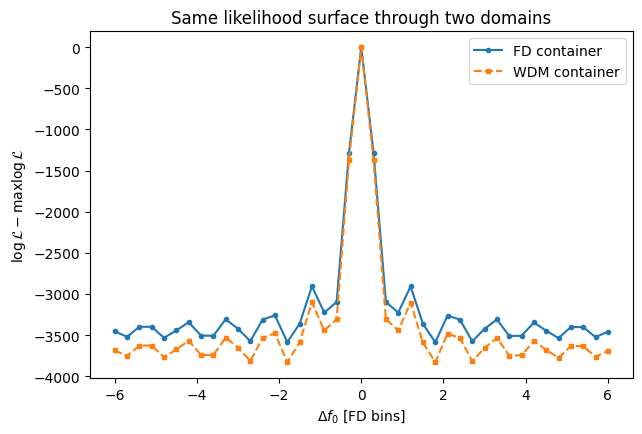

In [18]:
scan_ll_wdm = np.empty_like(offsets_bins)
t0 = time.perf_counter()
for i, ob in enumerate(offsets_bins):
    p = truth.copy()
    p[1] += ob * df
    scan_ll_wdm[i] = ac_wdm.calculate_signal_likelihood(*p, source_only=True)
print(f"WDM scan in {time.perf_counter() - t0:.2f} s (each point pays one FD->WDM transform)")

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(offsets_bins, scan_ll - scan_ll.max(), "o-", ms=3, label="FD container")
ax.plot(offsets_bins, scan_ll_wdm - scan_ll_wdm.max(), "s--", ms=3, label="WDM container")
ax.set_xlabel(r"$\Delta f_0$ [FD bins]")
ax.set_ylabel(r"$\log\mathcal{L} - \max \log\mathcal{L}$")
ax.set_title("Same likelihood surface through two domains")
ax.legend()
plt.show()

## 8. `AnalysisContainerArray`: batching containers per walker

An MCMC global fit holds one residual + sensitivity per **walker**. `AnalysisContainerArray` (ACA) wraps a list (or object
array) of `AnalysisContainer`s and:

- **repacks all data and inverse-PSD arrays into contiguous linear buffers** (`linear_data_arr` / `linear_psd_arr`), one per
  "split". Each container's `data.arr` and `sens_mat.invC` are re-pointed at *views into those buffers*, so per-walker
  in-place edits and buffer-level kernel calls see the same memory;
- provides **vectorized analysis ops** across the containers: `likelihood`, `inner_product`, `snr`,
  `calculate_signal_likelihood/_inner_product/_snr`, `template_*` — each returning per-walker arrays;
- provides **residual bookkeeping** (`add_signal_to_residual` / `remove_signal_from_residual`) with an optional `data_index`
  mapping templates to walkers;
- shards the containers across **GPUs** (`gpus=[...]`) or across **CPU threads** (`n_splits=`, `run_threaded=True`) through
  the same split machinery (`gpu_splits` / `split_map`).

This is exactly the object the global-fit engine builds in `RunGlobalFit.setup_acs`: one AC per walker (data deep-copied from
the input residual array, sensitivity rebuilt from the walker's current PSD parameters, per-branch `signal_gen` dict
registered), then wrapped into an ACA and handed to the moves.

We build a 4-walker ACA on the GB band. **Each walker gets its own `FDSignal` copy *and its own sensitivity-matrix
instance*** — the ACA re-points each container's `invC` into the shared PSD buffer, so sharing one matrix object across
walkers would silently alias their noise models (a real trap; see Section 9).

In [19]:
nwalkers = 4
walker_params = np.tile(truth, (nwalkers, 1))
walker_params[:, 1] += np.arange(nwalkers) * 3 * df  # walker 0 = truth; others offset in f0

acs_list = []
for w in range(nwalkers):
    d_w = FDSignal(injection_arr.copy(), fd_band)              # own data copy
    sm_w = XYZ2SensitivityMatrix(fd_band, model="sangria")     # own sens-mat instance!
    acs_list.append(AnalysisContainer(d_w, sm_w, signal_gen=gb_signal_gen))

aca = AnalysisContainerArray(acs_list, gpus=None)

print("num_acs:", aca.num_acs, "| acs_shape:", aca.acs_shape,
      "| nchannels:", aca.nchannels, "| data_length:", aca.data_length)
print("linear data buffer:", aca.linear_data_arr[0].shape, aca.linear_data_arr[0].dtype)
print("data_shaped[0] (walker, channel, bin):", aca.data_shaped[0].shape)
print("walker 0 data is a VIEW into the linear buffer:",
      np.shares_memory(aca.acs[0].data.arr, aca.linear_data_arr[0]))
print("per-walker start_freq_ind:", aca.start_freq_ind)

num_acs: 4 | acs_shape: (4,) | nchannels: 3 | data_length: 5243
linear data buffer: (62916,) complex128
data_shaped[0] (walker, channel, bin): (4, 3, 5243)
walker 0 data is a VIEW into the linear buffer: True
per-walker start_freq_ind: [13108 13108 13108 13108]


### 8.1 Vectorized likelihoods across walkers

`aca.calculate_signal_likelihood(params)` evaluates one parameter row per walker (row `i` against container `i`) and returns
the per-walker array. The optional `index=` argument generalizes this: `index[i]` names the container that row `i` targets,
so you can evaluate many proposals against one walker, a subset of walkers, or any row → walker mapping — this is the entry
point the samplers use. All values are returned as host NumPy arrays regardless of backend.

In [20]:
lls = aca.calculate_signal_likelihood(walker_params, source_only=True)
opt, det = aca.calculate_signal_snr(walker_params)

for w in range(nwalkers):
    print(f"walker {w}: f0 offset = {w * 3} bins | log L = {lls[w]:>12.4f} "
          f"| opt SNR = {opt[w]:.2f} | det SNR = {det[w]:.3f}")

# Row -> container mapping with index=: evaluate two proposals, both against walker 2
lls_idx = aca.calculate_signal_likelihood(
    walker_params[:2], index=np.array([2, 2]), source_only=True
)
print("\ntwo proposal rows, both evaluated on walker 2's data:", lls_idx)

# Data-only ops are vectorized the same way
print("per-walker <d|d>:", aca.inner_product())

walker 0: f0 offset = 0 bins | log L =      -0.0000 | opt SNR = 58.93 | det SNR = 58.929
walker 1: f0 offset = 3 bins | log L =   -3422.9887 | opt SNR = 58.95 | det SNR = 0.858
walker 2: f0 offset = 6 bins | log L =   -3455.9244 | opt SNR = 58.96 | det SNR = 0.316
walker 3: f0 offset = 9 bins | log L =   -3462.8576 | opt SNR = 58.98 | det SNR = 0.216

two proposal rows, both evaluated on walker 2's data: [-2.91038305e-11 -3.42298867e+03]
per-walker <d|d>: [3472.57233338 3472.57233338 3472.57233338 3472.57233338]


### 8.2 Per-walker residual bookkeeping

Naming convention alert: **`add_signal_to_residual` *subtracts* templates from the stored arrays** (the stored array is a
*residual* and residual = data − signal, so "adding a signal to the residual" removes it from the array), and
`remove_signal_from_residual` adds them back. Both delegate to `signal_operation(sign, templates, data_index=...)`, which is
domain-aware (partial band overlap is handled per domain via `DomainBase.add_signal`).

We subtract each walker's (slightly offset) template, look at the per-walker source-only log-likelihoods of the residuals,
and then restore. Walker 0 (the exact template) collapses to zero; the offset walkers leave residual power behind. This is
precisely the global-fit rhythm: `setup_acs(state, rebuild_residuals=True)` builds fresh data copies and subtracts every
branch's current templates, and in-model moves subtract/re-add per-source templates around each proposal.

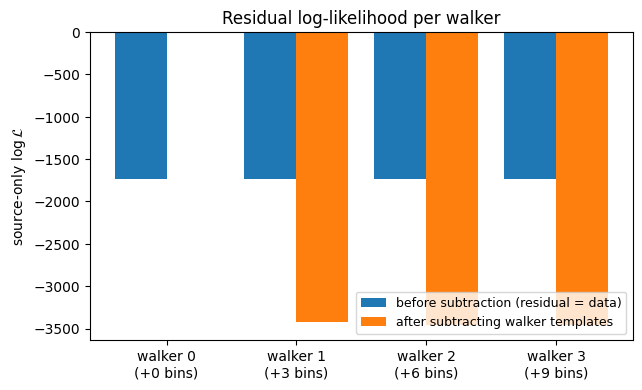

restored == original: True


after targeted subtraction: [-1.73628617e+03 -5.73333130e-28 -1.73628617e+03 -7.01787373e-28]


In [21]:
templates = [gb_signal_gen(*walker_params[w]) for w in range(nwalkers)]

ll_data = aca.likelihood(source_only=True)          # residual == data
aca.add_signal_to_residual(templates)               # SUBTRACTS (residual = data - h)
ll_resid = aca.likelihood(source_only=True)
aca.remove_signal_from_residual(templates)          # adds back
ll_restored = aca.likelihood(source_only=True)

x = np.arange(nwalkers)
fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(x - 0.2, ll_data, width=0.4, label="before subtraction (residual = data)")
ax.bar(x + 0.2, ll_resid, width=0.4, label="after subtracting walker templates")
ax.set_xticks(x, [f"walker {w}\n(+{3 * w} bins)" for w in x])
ax.set_ylabel(r"source-only $\log\mathcal{L}$")
ax.legend(loc="lower right", fontsize=9)
ax.set_title("Residual log-likelihood per walker")
plt.show()

print("restored == original:", np.allclose(ll_restored, ll_data))

# data_index: subtract ONE template from a subset of walkers (here the truth template
# from walkers 1 and 3), leaving the others untouched.
aca.add_signal_to_residual([templates[0], templates[0]], data_index=np.array([1, 3]))
print("after targeted subtraction:", aca.likelihood(source_only=True))
aca.remove_signal_from_residual([templates[0], templates[0]], data_index=np.array([1, 3]))

### 8.3 CPU splits and threading

With `gpus=[...]` the containers are sharded across CUDA devices (each shard's buffers allocated on its owning device, ops
executed inside the right device context). On CPU-only machines the same split structure is exposed through `n_splits=`:
the containers are partitioned into that many splits, and `run_threaded=True` executes the per-split batches concurrently
(one thread per split). Threads pay off when the per-row work releases the GIL (large-array NumPy/BLAS/FFT, GIL-releasing
C++ kernels); for the small arrays here it is just a structural demonstration.

In [22]:
aca_threaded = AnalysisContainerArray(acs_list, gpus=None, n_splits=2, run_threaded=True)
print("split sizes:", [len(s) for s in aca_threaded.gpu_splits],
      "| split_map:", aca_threaded.split_map)

lls_threaded = aca_threaded.calculate_signal_likelihood(walker_params, source_only=True)
print("threaded per-walker log L :", np.round(lls_threaded, 4))
print("matches serial            :", np.allclose(lls_threaded, lls))

split sizes: [2, 2] | split_map: [0 0 1 1]
threaded per-walker log L : [   -0.     -3422.9887 -3455.9244 -3462.8576]
matches serial            : True


## 9. Practical gotchas

Real behaviors observed while building this notebook — worth knowing before using the containers in anger:

1. **`add_signal_to_residual` subtracts.** On `AnalysisContainerArray`, `add_signal_to_residual` applies `sign=-1`
   (residual = data − signal) and `remove_signal_from_residual` applies `sign=+1`. On a single container /
   `DomainBase`, `add_signal(..., sign=...)` / `subtract_signal(...)` mean what they say. Read twice, subtract once.

2. **One sensitivity-matrix instance per container inside an ACA.** `AnalysisContainerArray.__init__` re-points every
   container's `sens_mat.invC` (and `data.arr`) at views into its contiguous per-split buffers. If two containers share one
   `SensitivityMatrix` object, the second re-point silently aliases the first walker's noise weighting. Build a fresh matrix
   per container (cheap — the PSD evaluation is vectorized).

3. **ACA construction moves your arrays.** After `AnalysisContainerArray(acs)`, `ac.data.arr` is a *view into
   `aca.linear_data_arr[split]`* (`np.shares_memory(...) == True` above). In-place edits through either handle are visible
   through both — that is the point — but holding on to the pre-construction arrays buys you nothing.

4. **Templates for `template_*` must live on the data's exact settings** (same `N`, `df`, band). Automatic region slicing
   currently exists only for the STFT domain; in FD/WDM a settings mismatch raises. Generator outputs are more forgiving:
   `signal_gen` returns are auto-transformed into the data's domain (`_to_data_domain`), including cross-domain (FD → WDM).
   But note that an FD → FD *band change* is not performed by `transform` — construct the template directly on the data's
   band settings (an `FDSignal` built from a full-grid array with band-limited settings slices itself automatically).

5. **Transform to other domains from the full FD grid, not from a band-limited signal.** `FDSignal.pad_array` (used by
   `ifft`/`wdmtransform` to re-inflate a trimmed band before the inverse FFT) currently pads back to `N − 1` bins instead of
   `N` — i.e. a band-limited FD signal comes back shifted by one bin (and full-band signals with `ind_min = 0` would hit a
   negative pad). Keeping a full-grid `FDSignal` around for conversions avoids the path entirely (that is what this notebook
   does).

6. **A full-grid FD sensitivity (including $f = 0$) breaks the noise term.** The stock PSDs are NaN at DC, and
   `likelihood(noise_only=True)` asserts that either no basis element or every channel block is NaN. Band-limit the FD
   settings (`min_freq >= df`) — which you want anyway — and the problem never appears.

7. **Band edges snap to the grid.** FD: `ind_min = ceil(min_freq / df)`; WDM: whole layers, `ind_min_f = ceil(min_freq /
   layer_df)`. Two "identically banded" FD and WDM settings therefore cover slightly different physical bands; irrelevant for
   a narrowband source well inside the band, but worth remembering when comparing absolute band-limited quantities.

8. **WDM absolute normalization is layer-resolution dependent.** The wavelet-domain noise weighting samples the PSD at
   `layer_df` granularity, so absolute $\langle d|d\rangle$/SNR differ from FD by (PSD variation across a layer) — ~7% at
   `Nf = 256` here, converging to the FD value as `Nf` grows (Section 7.2). Relative quantities (mismatch, likelihood
   ratios/shape) are unaffected.

9. **`normalize=True, complex=True` is the mismatch idiom.** `template_inner_product(h, normalize=True, complex=True)`
   returns the complex normalized overlap; `1 - abs(...)` is the mismatch used throughout the sprint's validation
   thresholds. `normalize` also accepts `"sig1"`/`"sig2"` to normalize by a single signal's power.

10. **Arrays may be CuPy.** With `force_backend="cuda12x"` on the settings, every derived array (data, `invC`, templates)
    is a `cupy.ndarray`; scalar results from the container ops come back as host floats, and ACA vectorized ops return host
    NumPy arrays. Follow the `xp` pattern (`signal.xp`, `get_array_module`) in your own code rather than assuming NumPy —
    and never mix backends across objects in one container.

11. **`data_index` (and `index`) are integer arrays into the *flat* container list**, `0 <= data_index[i] < num_acs`, mapping
    row `i` of your templates/params to a container. `None` means one row per container, in order (lengths must match).

12. **`DataResidualArray` is deprecated.** Pass `FDSignal` / `WDMSignal` / `TDSignal` / `STFTSignal` directly. Legacy
    attribute chains (`ac.data_res_arr.data_res_arr`) still resolve because `DomainBase.data_res_arr` is a self-reference.

## Wrap-up

- `AnalysisContainer` = data (`DomainBase`) + noise (`SensitivityMatrixBase`) + optional `signal_gen`, exposing inner
  products, SNRs, overlaps/mismatches, and likelihoods with one API across FD, WDM, TD, and STFT bases.
- Registering `signal_gen` (a callable or a per-model dict) turns it into a parameters → likelihood machine, with automatic
  domain conversion of generator outputs.
- `AnalysisContainerArray` batches per-walker containers into contiguous buffers, vectorizes every op across walkers
  (with arbitrary row → walker `index` maps), handles residual add/subtract bookkeeping, and shards across GPUs or CPU
  threads — it is the object the global-fit engine and its moves operate on.

For the surrounding machinery, see `lisatools_tutorial.ipynb` (sensitivities, orbits, diagnostics),
`time_frequency_domains_tutorial.ipynb` / `wdm_transform_tutorial.ipynb` (domain classes in depth), and
`stock_global_fit_tutorial.ipynb` (the full global-fit pipeline that consumes these containers).